In [1]:
import data_poisoning_attack

c:\Users\uiv09218\AppData\Local\miniforge3\envs\xai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...
Training model...
Model test accuracy: 0.7273
Preparing attack prerequisites...
Starting evolution...
Start population fitness calculation:
	Concatenating population took 0.0035686492919921875 seconds.
	Producing SHAP explanations took 365.92802929878235 seconds.
	Producing SHAP reference explanations took 0.0 seconds.
	Calculating drift scores took 0.03689384460449219 seconds.
	Calculating estimated probs took 0.0 seconds.
	Calculating LCB took 0.0 seconds.
Calculating optimization metrics took 365.96849179267883 seconds.
Initial Population - Best Fitness: 2.719547 --- Time: 365.97s
before evolution --- Time: 365.97s
--- produced next generation --- Time: 366.02s
Start population fitness calculation:
	Concatenating population took 0.0 seconds.
	Producing SHAP explanations took 369.4089984893799 seconds.
	Producing SHAP reference explanations took 0.0 seconds.
	Calculating drift scores took 0.031252384185791016 seconds.
	Calculating estimated probs took 0.0 seconds.
	Ca

TypeError: Individual.mutate() got an unexpected keyword argument 'cat_mask'

In [27]:
import pickle
import data_poisoning as dp
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import copy
import numpy as np

In [28]:
with open("evolution_results_25p_4s_40g_0.3dt_0.95dc.pkl", "rb") as f:
    eval_results = pickle.load(f)

In [29]:
eval_results['early_stopping'].best_stds

array([0.017258  , 0.01843743, 0.02351082, 0.01751147, 0.01830297,
       0.02947557, 0.02756795, 0.02494899])

In [30]:
eval_individual = dp.Individual(
    data=eval_results['X_train'].values.copy(),
    mutation_rate=1.0,
    mutation_stds=eval_results['early_stopping'].best_stds
)

sample = [copy.deepcopy(eval_individual) for _ in range(10)]

for s in sample:
    s.mutate(
        X_min=eval_results['X_train'].values.min(axis=0),
        X_max=eval_results['X_train'].values.max(axis=0),
        X_cat=eval_results['X_train'].shape[1]*[None]
    )

In [31]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=3368494378,
    n_jobs=-1
)

In [32]:
model.fit(eval_results['X_train'].values, eval_results['y_train'].values)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
explainer = dp.shap.Explainer(model)

reference_explanations = dp.produce_shap_explanations(
    explainer,
    eval_results['X_train'].values
)

In [35]:
for s in sample:
    print(s.data.shape)

(691, 8)
(691, 8)
(691, 8)
(691, 8)
(691, 8)
(691, 8)
(691, 8)
(691, 8)
(691, 8)
(691, 8)


0.9913169319826338
r: (8,)
m: (8,)


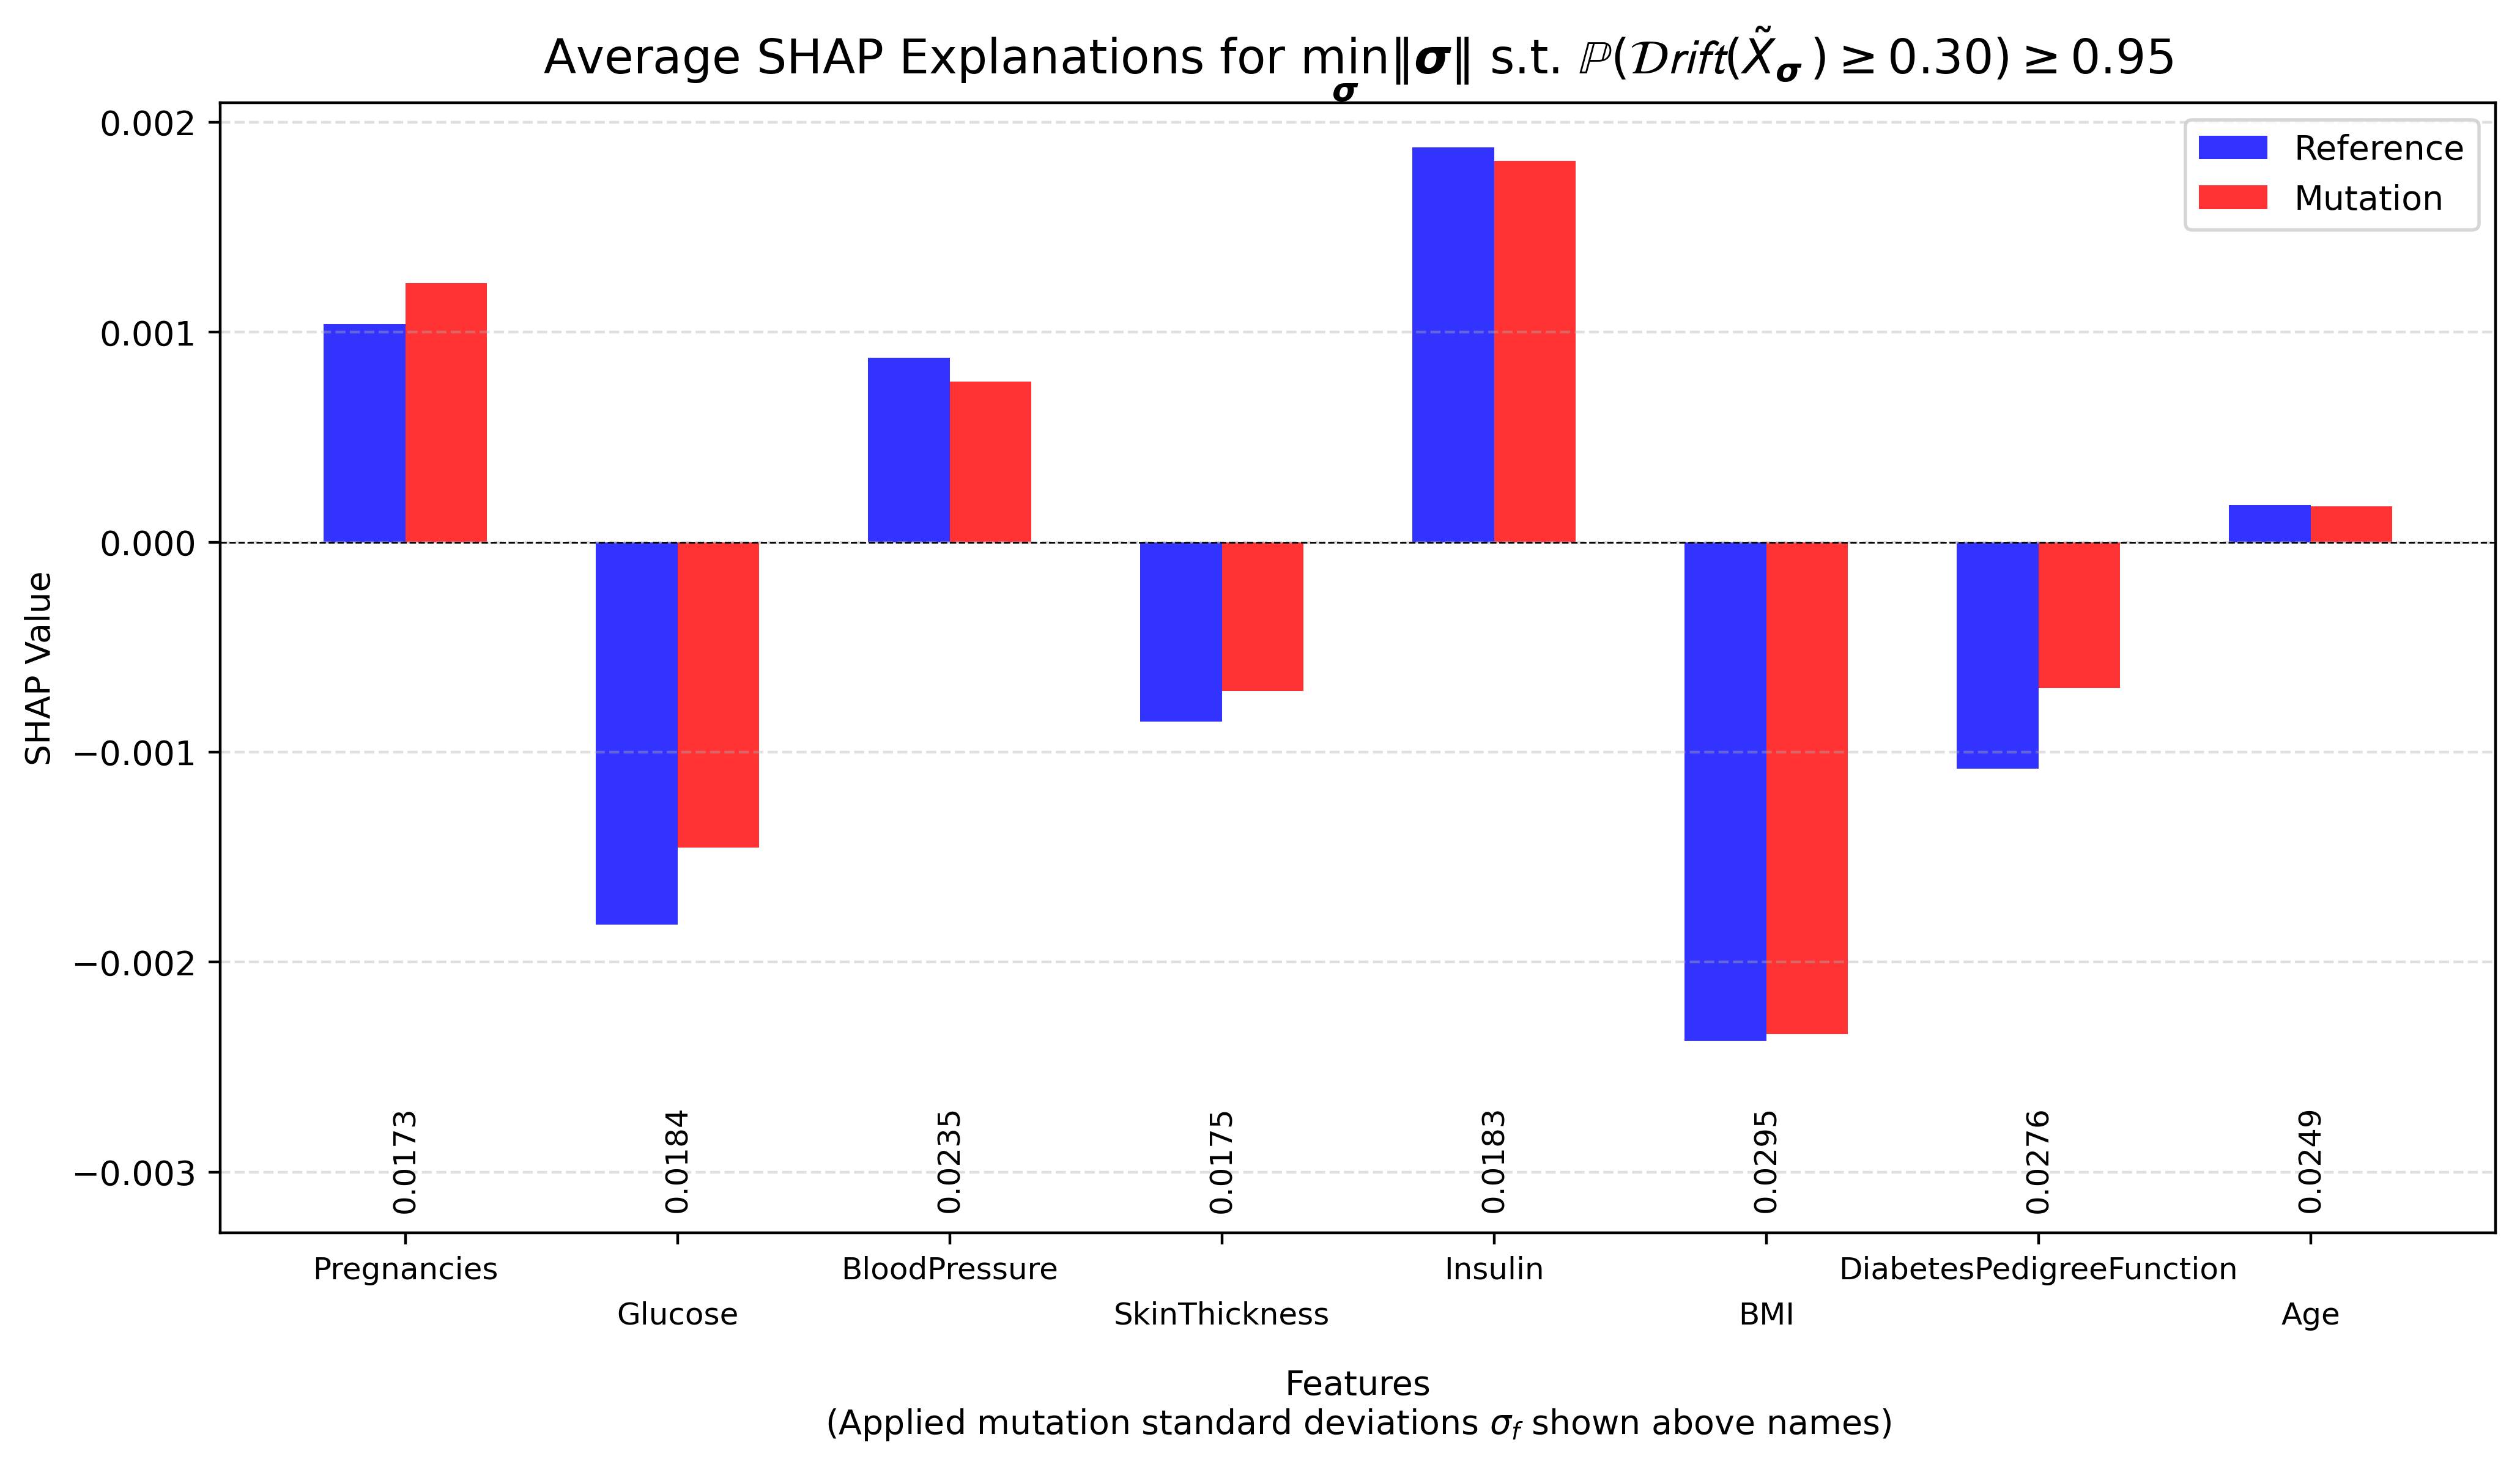

In [40]:
reference_predictions = model.predict(eval_results['X_train'].values)
mutation_predictions = np.ones_like(reference_predictions)
for s in sample:
    mutation_predictions *= model.predict(s.data)
correct_prediction = reference_predictions == mutation_predictions

print(correct_prediction.mean())

global_mutation_explanations = np.zeros(reference_explanations[correct_prediction].shape, dtype=float)
for s in sample:
    global_mutation_explanations += dp.produce_shap_explanations(
        explainer,
        s.data
    )[correct_prediction]
global_mutation_explanations /= len(sample)

print("r:", reference_explanations[correct_prediction].mean(axis=0).shape)
print("m:", global_mutation_explanations.mean(axis=0).shape)

eval_plot = dp.plot_evaluation(
    global_reference_explanations=reference_explanations[correct_prediction].mean(axis=0),
    global_mutation_explanations=global_mutation_explanations.mean(axis=0),
    standard_deviations=eval_individual.mutation_stds,
    feature_names=eval_results['X_train'].columns.tolist(),
    drift_threshold=0.3,
    drift_confidence=0.95
)